# **Training, testing and evaluation of linear and nonlinear models for WM**

###**Linear Models**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load dataset
data = pd.read_csv('DTI_final.csv')

# Select ROI features
roi_columns = [col for col in data.columns if col.startswith('ROI')]
data = data[['CCID'] + roi_columns + ['Sex', 'Age']]

# Encode categorical feature (Sex)
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

# Define predictors and target
X = data[roi_columns + ['Sex']].values
y = data['Age'].values
ccid = data['CCID'].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset into training (80%) and validation (20%)
train_df, valid_df = train_test_split(data, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test, ccid_train, ccid_test = train_test_split(
    X, y, ccid, test_size=0.2, random_state=RANDOM_SEED, shuffle=True
)

# Define hyperparameter grids
param_grids = {
    "RidgeRegression": {'alpha': [0.01, 0.1, 1, 10, 100]},
    "LassoRegression": {'alpha': [0.01, 0.1, 1, 10, 100]},
    "ElasticNet": {'alpha': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.1, 0.5, 0.9]}
}

# Linear models
linear_models = {
    "RidgeRegression": Ridge(random_state=RANDOM_SEED, max_iter=100000),
    "LassoRegression": Lasso(random_state=RANDOM_SEED, max_iter=100000),
    "ElasticNet": ElasticNet(random_state=RANDOM_SEED, max_iter=100000)
}

# Train and evaluate models with 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results = {}
best_params = {}

for model_name, model in linear_models.items():
    best_params[model_name] = []
    best_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        grid_search = GridSearchCV(model, param_grids[model_name], cv=5)
        grid_search.fit(X_train_fold, y_train_fold)

        # Print only the best parameters and their score
        print(f"{model_name} - Fold {fold_idx+1} Best Parameters: {grid_search.best_params_}, Best CV Score: {grid_search.best_score_:.4f}")

        best_params[model_name].append(grid_search.best_params_)
        best_scores.append(grid_search.best_score_)

    # Train on the full training set with the best parameters from cross-validation
    best_param = max(zip(best_params[model_name], best_scores), key=lambda x: x[1])[0]
    final_model = model.set_params(**best_param)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mean_age_gap = np.mean(np.abs(y_test - y_pred))

    results[model_name] = {'MSE': mse, 'MAE': mae, 'R²': r2, 'Mean_Age_Gap': mean_age_gap}

# Print final results
print("\nModel Performance (5-Fold Cross-Validation):")
for model_name, metrics in results.items():
    print(f"{model_name} - MSE: {metrics['MSE']:.4f}, MAE: {metrics['MAE']:.4f}, R²: {metrics['R²']:.4f}, Mean Age Gap: {metrics['Mean_Age_Gap']:.4f}")

RidgeRegression - Fold 1 Best Parameters: {'alpha': 100}, Best CV Score: 0.7895
RidgeRegression - Fold 2 Best Parameters: {'alpha': 100}, Best CV Score: 0.7992
RidgeRegression - Fold 3 Best Parameters: {'alpha': 100}, Best CV Score: 0.8069
RidgeRegression - Fold 4 Best Parameters: {'alpha': 100}, Best CV Score: 0.7883
RidgeRegression - Fold 5 Best Parameters: {'alpha': 100}, Best CV Score: 0.7951
LassoRegression - Fold 1 Best Parameters: {'alpha': 1}, Best CV Score: 0.7762
LassoRegression - Fold 2 Best Parameters: {'alpha': 0.1}, Best CV Score: 0.7901
LassoRegression - Fold 3 Best Parameters: {'alpha': 0.1}, Best CV Score: 0.7882
LassoRegression - Fold 4 Best Parameters: {'alpha': 0.1}, Best CV Score: 0.7784
LassoRegression - Fold 5 Best Parameters: {'alpha': 1}, Best CV Score: 0.7640
ElasticNet - Fold 1 Best Parameters: {'alpha': 1, 'l1_ratio': 0.1}, Best CV Score: 0.7970
ElasticNet - Fold 2 Best Parameters: {'alpha': 1, 'l1_ratio': 0.1}, Best CV Score: 0.7961
ElasticNet - Fold 3 Best

**Top 10 Features for WM Age Prediction (Lasso)**



Lasso FINAL (alpha=0.1) - MSE: 55.0708, MAE: 5.6716, R²: 0.8502, Mean Age Gap: 5.6716


/tmp/ipython-input-1544862369.py:59: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


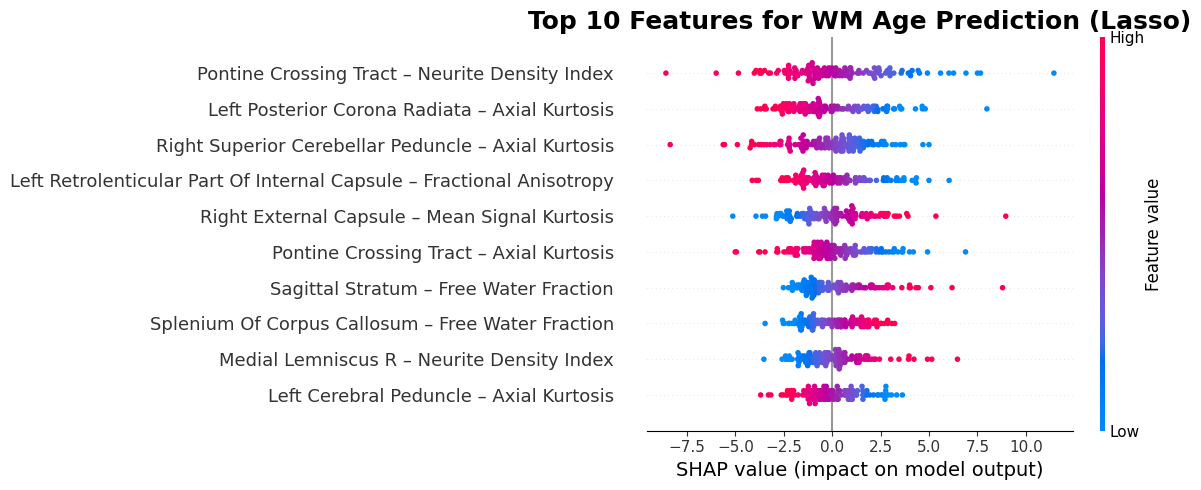

In [ ]:
# ===== Lasso(alpha=0.1) + SHAP =====
import shap
from sklearn.linear_model import Lasso

# 1) Fix alpha=0.1 and train the model
lasso_final = Lasso(alpha=0.1, random_state=RANDOM_SEED, max_iter=100000)
lasso_final.fit(X_train, y_train)

# 2) Simple evaluation
y_pred = lasso_final.predict(X_test)
print(
    f"Lasso FINAL (alpha=0.1) - MSE: {mean_squared_error(y_test, y_pred):.4f}, "
    f"MAE: {mean_absolute_error(y_test, y_pred):.4f}, "
    f"R²: {r2_score(y_test, y_pred):.4f}, "
    f"Mean Age Gap: {np.mean(np.abs(y_test - y_pred)):.4f}"
)

# 3) Compute SHAP values
feature_names_all = roi_columns + ["Sex"]   # Same order as X construction
explainer = shap.LinearExplainer(lasso_final, X_train, feature_names=feature_names_all)
sv = explainer(X_test)   # Calculate SHAP only on the test set

# 4) Feature importance (mean absolute SHAP value)
sv_values = sv.values if hasattr(sv, "values") else sv
imp = np.abs(sv_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names_all,
    "Importance": imp
}).sort_values("Importance", ascending=False)

# --- Define a filter function: whether the feature is AD or RD (case-insensitive) ---
ad_rd_pat = re.compile(r"_([Aa][Dd]|[Rr][Dd])$")

def is_ad_or_rd(feat: str) -> bool:
    # Only check ROI_*_* names; keep "Sex"
    return feat.startswith("ROI_") and bool(ad_rd_pat.search(feat))

# 5) Filter out AD/RD features and then select Top 10
feature_importance_no_adrd = feature_importance[~feature_importance["Feature"].apply(is_ad_or_rd)]

# Ensure proper sorting by importance before selecting top 10
feature_importance_no_adrd = feature_importance_no_adrd.sort_values("Importance", ascending=False)

# Safety fallback: if fewer than 10 remain, take all
topK = 10
topk_df = feature_importance_no_adrd.head(topK).copy()

# Align with original sv / X_test indices
topk_idx = [feature_names_all.index(f) for f in topk_df["Feature"]]
shap_topk = sv_values[:, topk_idx]
X_topk = X_test[:, topk_idx]

# 6) Map feature names to pretty labels (using your pretty_name function)
names_topk_pretty = [pretty_name(f) for f in topk_df["Feature"]]

# 7) Plot SHAP summary for Top 10 features
plt.figure(figsize=(30, 20))
shap.summary_plot(
    shap_topk,
    X_topk,
    feature_names=names_topk_pretty,
    plot_type="dot",
    show=False,
    plot_size=(12, 5)
)
plt.title("Top 10 Features for WM Age Prediction (Lasso)", fontsize=18, weight="bold")
plt.xlabel("SHAP value (impact on model output)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_top10_lasso_alpha01.png", dpi=300, bbox_inches="tight")
plt.show()

**ROI Dictionary**

In [ ]:
import re

# ROI index → anatomical region name
ROI_INDEX_TO_NAME = {
    1: "Unclassified",
    2: "Middle Cerebellar Peduncle",
    3: "Pontine Crossing Tract",
    4: "Genu Of Corpus Callosum",
    5: "Body Of Corpus Callosum",
    6: "Splenium Of Corpus Callosum",
    7: "Fornix",
    8: "Corticospinal Tract R",
    9: "Corticospinal Tract L",
    10: "Medial Lemniscus R",
    11: "Medial Lemniscus L",
    12: "Right Inferior Cerebellar Peduncle",
    13: "Left Inferior Cerebellar Peduncle",
    14: "Right Superior Cerebellar Peduncle",
    15: "Left Superior Cerebellar Peduncle",
    16: "Right Cerebral Peduncle",
    17: "Left Cerebral Peduncle",
    18: "Right Anterior Limb Of Internal Capsule",
    19: "Left Anterior Limb Of Internal Capsule",
    20: "Right Posterior Limb Of Internal Capsule",
    21: "Left Posterior Limb Of Internal Capsule",
    22: "Right Retrolenticular Part Of Internal Capsule",
    23: "Left Retrolenticular Part Of Internal Capsule",
    24: "Right Anterior Corona Radiata",
    25: "Left Anterior Corona Radiata",
    26: "Right Superior Corona Radiata",
    27: "Left Superior Corona Radiata",
    28: "Right Posterior Corona Radiata",
    29: "Left Posterior Corona Radiata",
    30: "Posterior Thalamic Radiation",
    31: "Posterior Thalamic Radiation",
    32: "Sagittal Stratum",
    33: "Sagittal Stratum",
    34: "Right External Capsule",
    35: "Left External Capsule",
    36: "Cingulum",
    37: "Cingulum",
    38: "Cingulum",
    39: "Cingulum",
    40: "Fornix",
    41: "Fornix",
    42: "Right Superior Longitudinal Fasciculus",
    43: "Left Superior Longitudinal Fasciculus",
    44: "Superior Fronto-Occipital Fasciculus",
    45: "Superior Fronto-Occipital Fasciculus",
    46: "Right Uncinate Fasciculus",
    47: "Left Uncinate Fasciculus",
    48: "Right Tapetum",
    49: "Left Tapetum",
}

# Metric abbreviation → full name
METRIC_MAP = {
    "FA":  "Fractional Anisotropy",
    "MD":  "Mean Signal Diffusivity",
    "AK":  "Axial Kurtosis",
    "MK":  "Mean Signal Kurtosis",
    "NDI": "Neurite Density Index",
    "FISO": "Free Water Fraction",
    "OD": "Orientation Dispersion Index",
    "ND": "Neurite Density Index",
    "RK": "Radial Kurtosis"
}

roi_pat = re.compile(r"^ROI_(\d+)_([A-Za-z0-9]+)$")

def pretty_name(feature: str) -> str:
    if feature == "Sex":
        return "Sex (label encoded)"
    m = roi_pat.match(feature)
    if not m:
        return feature
    idx = int(m.group(1))
    metric = m.group(2).upper()
    region = ROI_INDEX_TO_NAME.get(idx, f"ROI {idx}")
    metric_full = METRIC_MAP.get(metric, metric)
    return f"{region} – {metric_full}"

**Different Seeds**

In [ ]:
# Perform cross-validation and save Ridge, Lasso, and ElasticNet results
def perform_model_cv_and_save(X, y, seeds=[42, 7, 123, 99, 56, 78]):
    models = {
        "RidgeRegression": Ridge(alpha=100, max_iter=100000),
        "LassoRegression": Lasso(alpha=0.1, max_iter=100000),
        "ElasticNet": ElasticNet(alpha=1, l1_ratio=0.9, max_iter=100000)
    }

    metrics_results = {model_name: {seed: None for seed in seeds} for model_name in models.keys()}

    # Perform cross-validation
    for model_name, model in models.items():
        for seed in seeds:
            np.random.seed(seed)
            kf = KFold(n_splits=10, shuffle=True, random_state=seed)

            metrics = {'MSE': [], 'MAE': [], 'R²': [], 'Mean_Age_Gap': []}

            for train_index, test_index in kf.split(X):
                X_train_cv, X_test_cv = X[train_index], X[test_index]
                y_train_cv, y_test_cv = y[train_index], y[test_index]

                model.fit(X_train_cv, y_train_cv)
                y_pred_cv = model.predict(X_test_cv)

                metrics['MSE'].append(mean_squared_error(y_test_cv, y_pred_cv))
                metrics['MAE'].append(mean_absolute_error(y_test_cv, y_pred_cv))
                metrics['R²'].append(r2_score(y_test_cv, y_pred_cv))
                metrics['Mean_Age_Gap'].append(np.mean(np.abs(y_test_cv - y_pred_cv)))

            metrics_results[model_name][seed] = {metric: np.mean(values) for metric, values in metrics.items()}

    # Visualize different evaluation metrics and save as PNG
    metrics_list = ['MSE', 'MAE', 'R²', 'Mean_Age_Gap']
    colors = sns.color_palette("husl", len(models))
    saved_files = []

    for metric_idx, metric_name in enumerate(metrics_list):
        plt.figure(figsize=(10, 6))

        for model_idx, (model_name, model) in enumerate(models.items()):
            metric_values = [metrics_results[model_name][seed][metric_name] for seed in seeds]
            plt.scatter(seeds, metric_values, label=f"{model_name} - {metric_name}", color=colors[model_idx])
            plt.plot(seeds, metric_values, linestyle='-', color=colors[model_idx])

        plt.ylim(min(min(metrics_results[m][s][metric_name] for s in seeds) for m in models) * 0.9,
                 max(max(metrics_results[m][s][metric_name] for s in seeds) for m in models) * 1.1)

        plt.title(f'{metric_name} Across Different Seeds')
        plt.xlabel('Seed')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Save the plot
        filename = f"{metric_name}_comparison_across_seeds.png"
        plt.savefig(filename)
        saved_files.append(filename)
        plt.close()

    return saved_files

# Run the model evaluation
saved_images = perform_model_cv_and_save(X_train, y_train)
print("done", saved_images)

done ['MSE_comparison_across_seeds.png', 'MAE_comparison_across_seeds.png', 'R²_comparison_across_seeds.png', 'Mean_Age_Gap_comparison_across_seeds.png']


### **Nonlinear model**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load dataset
data = pd.read_csv('DTI_final.csv')

# Select ROI features
roi_columns = [col for col in data.columns if col.startswith('ROI')]
data = data[['CCID'] + roi_columns + ['Sex', 'Age']]

# Encode categorical feature (Sex)
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

# Define predictors and target
X = data[roi_columns + ['Sex']].values
y = data['Age'].values
ccid = data['CCID'].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset into training (80%) and validation (20%)
X_train, X_test, y_train, y_test, ccid_train, ccid_test = train_test_split(
    X, y, ccid, test_size=0.2, random_state=RANDOM_SEED, shuffle=True
)

# Hyperparameter grids
param_grids = {
    "RandomForest": {'n_estimators': [50, 100, 150], 'max_depth': [10, 20, 30]},
    "XGBoost": {'n_estimators': [50, 100, 150],
                'learning_rate': [0.05, 0.1, 0.2],
                'max_depth': [3, 5, 7]}
}

# Non-linear models
nonlinear_models = {
    "RandomForest": RandomForestRegressor(random_state=RANDOM_SEED),
    "XGBoost": XGBRegressor(random_state=RANDOM_SEED)
}

# Train and evaluate models with 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results = {}
best_params = {}

for model_name, model in nonlinear_models.items():
    best_params[model_name] = []
    best_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        grid_search = RandomizedSearchCV(model, param_grids[model_name],
                                         cv=3, n_iter=5, random_state=RANDOM_SEED, n_jobs=-1)
        grid_search.fit(X_train_fold, y_train_fold)

        best_score = grid_search.score(X_val_fold, y_val_fold)

        print(f"{model_name} - Fold {fold_idx+1} Best Parameters: {grid_search.best_params_}, "
              f"Best CV Score: {best_score:.4f}")

        best_params[model_name].append(grid_search.best_params_)
        best_scores.append(best_score)

    # Train on the full training set with the best parameters
    best_param = max(zip(best_params[model_name], best_scores), key=lambda x: x[1])[0]
    final_model = model.set_params(**best_param)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mean_age_gap = np.mean(np.abs(y_test - y_pred))

    results[model_name] = {'MSE': mse, 'MAE': mae, 'R²': r2, 'Mean_Age_Gap': mean_age_gap}

print("\nModel Performance (5-Fold Cross-Validation):")
for model_name, metrics in results.items():
    print(f"{model_name} - MSE: {metrics['MSE']:.4f}, "
          f"MAE: {metrics['MAE']:.4f}, "
          f"R²: {metrics['R²']:.4f}, "
          f"Mean Age Gap: {metrics['Mean_Age_Gap']:.4f}")

RandomForest - Fold 1 Best Parameters: {'n_estimators': 150, 'max_depth': 20}, Best CV Score: 0.7891
RandomForest - Fold 2 Best Parameters: {'n_estimators': 150, 'max_depth': 20}, Best CV Score: 0.7858
RandomForest - Fold 3 Best Parameters: {'n_estimators': 150, 'max_depth': 20}, Best CV Score: 0.7031
RandomForest - Fold 4 Best Parameters: {'n_estimators': 100, 'max_depth': 30}, Best CV Score: 0.7414
RandomForest - Fold 5 Best Parameters: {'n_estimators': 150, 'max_depth': 20}, Best CV Score: 0.7495
XGBoost - Fold 1 Best Parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}, Best CV Score: 0.8003
XGBoost - Fold 2 Best Parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}, Best CV Score: 0.7991
XGBoost - Fold 3 Best Parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}, Best CV Score: 0.7407
XGBoost - Fold 4 Best Parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}, Best CV Score: 0.7702
XGBoost - Fold 5 Best Parameter

### **Bias Correction**


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

def bias_correction(y_true_train, y_pred_train, y_pred_test):
    """
    Bias correction for brain age prediction

    Parameters:
    -----------
    y_true_train : array-like
        Chronological ages in the training set
    y_pred_train : array-like
        Predicted brain ages in the training set
    y_pred_test : array-like
        Predicted brain ages in the test set

    Returns:
    --------
    y_pred_test_corrected : array-like
        Bias-corrected predicted ages for the test set
    alpha, beta : float
        Correction coefficients
    """
    # Fit linear model: y_pred_train = alpha * y_true_train + beta
    reg = LinearRegression().fit(y_true_train.reshape(-1, 1), y_pred_train)
    alpha = reg.coef_[0]
    beta = reg.intercept_

    print(f"Estimated correction coefficients: alpha={alpha:.4f}, beta={beta:.4f}")

    # Correct test predictions
    y_pred_test_corrected = (y_pred_test - beta) / alpha

    return y_pred_test_corrected, alpha, beta

In [ ]:
# ===== Apply bias correction to Lasso =====
y_pred_train_lasso = final_model.predict(X_train)

y_pred_test_lasso = final_model.predict(X_test)

y_pred_test_corrected, alpha, beta = bias_correction(
    y_true_train=y_train,
    y_pred_train=y_pred_train_lasso,
    y_pred_test=y_pred_test_lasso
)

Estimated correction coefficients: alpha=0.8070, beta=10.5550
